In [0]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, StandardScaler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
from pyspark.ml.evaluation import BinaryClassificationEvaluator, RegressionEvaluator

from pyspark.sql.types import IntegerType, StringType, DoubleType
import numpy as np


In [0]:
base_path = "/Volumes/workspace/default/phase3"

df_gtfs_static = spark.read.parquet(f"{base_path}/gtfs_static_dataset.parquet")
df_rt_gtfs     = spark.read.parquet(f"{base_path}/RT_gtfs_Sep.parquet")
df_events      = (
    spark.read
         .option("header", True)
         .option("inferSchema", True)
         .csv(f"{base_path}/Boston_Events.csv")
)

print("Static:", df_gtfs_static.count(), "rows")
print("LAMP  :", df_rt_gtfs.count(), "rows")
print("Events:", df_events.count(), "rows")


Static: 2317392 rows
LAMP  : 1312273 rows
Events: 9672 rows


In [0]:
import requests
import pandas as pd
from pyspark.sql import functions as F

# --- FETCH ACTUAL WEATHER FOR SEP 2025 ---
# Since this date has passed, we can query the 'archive' API directly for the real data.
weather_url = (
    "https://archive-api.open-meteo.com/v1/archive?"
    "latitude=42.36&longitude=-71.06&start_date=2025-09-01&end_date=2025-09-30" 
    "&hourly=temperature_2m,rain,wind_speed_10m"
)

response = requests.get(weather_url)
weather_data = response.json()

pdf_weather = pd.DataFrame({
    'time': weather_data['hourly']['time'],
    'temp_c': weather_data['hourly']['temperature_2m'],
    'rain_mm': weather_data['hourly']['rain'],
    'wind_kph': weather_data['hourly']['wind_speed_10m']
})

# Convert to Spark
df_weather = spark.createDataFrame(pdf_weather)

# Clean and Prepare for Join
df_weather = df_weather.withColumn("weather_ts", F.to_timestamp("time")) \
    .withColumn("service_date", F.to_date("weather_ts")) \
    .withColumn("hour", F.hour("weather_ts")) \
    .select("service_date", "hour", "temp_c", "rain_mm", "wind_kph")

print("Actual Sep 2025 Weather Loaded.")
df_weather.show(5)

Actual Sep 2025 Weather Loaded.
+------------+----+------+-------+--------+
|service_date|hour|temp_c|rain_mm|wind_kph|
+------------+----+------+-------+--------+
|  2025-09-01|   0|  19.9|    0.0|     7.3|
|  2025-09-01|   1|  18.8|    0.0|     4.6|
|  2025-09-01|   2|  17.7|    0.0|     3.2|
|  2025-09-01|   3|  16.9|    0.0|     1.4|
|  2025-09-01|   4|  16.4|    0.0|     4.3|
+------------+----+------+-------+--------+
only showing top 5 rows


In [0]:
display(df_gtfs_static.limit(5))
display(df_rt_gtfs.limit(5))
display(df_events.limit(5))

df_gtfs_static.printSchema()
df_rt_gtfs.printSchema()
df_events.printSchema()


trip_id,arrival_time,departure_time,stop_id,stop_sequence,stop_headsign,pickup_type,drop_off_type,timepoint,checkpoint_id,continuous_pickup,continuous_drop_off,route_id,service_id,trip_headsign,trip_short_name,direction_id,block_id,shape_id,wheelchair_accessible,trip_route_type,route_pattern_id,bikes_allowed,monday,tuesday,wednesday,thursday,friday,saturday,sunday,start_date,end_date,agency_id,route_short_name,route_long_name,route_desc,route_type,route_url,route_color,route_text_color,route_sort_order,route_fare_class,line_id,listed_route,network_id,stop_code,stop_name,stop_desc,platform_code,platform_name,stop_lat,stop_lon,zone_id,stop_address,stop_url,level_id,location_type,parent_station,wheelchair_boarding,municipality,on_street,at_street,vehicle_type
70505896,18900000000000,18900000000000,70036,1,null,0,1,0,ogmnl,null,null,Orange,RTL42025-hmo45011-Weekday-01,Forest Hills,null,0,O903_-1,903_0026,1,null,Orange-3-0,0,1,1,1,1,0,0,0,20250909,20251211,1,null,Orange Line,Rapid Transit,1,https://www.mbta.com/schedules/Orange,ED8B00,FFFFFF,10020,Rapid Transit,line-Orange,null,rapid_transit,70036,Oak Grove,Oak Grove - Orange Line,null,Orange Line,42.437735,-71.070875,RapidTransit,null,https://www.mbta.com/stops/place-ogmnl,level_0_platform,0,place-ogmnl,1,Malden,null,null,1
70505896,18960000000000,18960000000000,70034,10,null,0,0,0,mlmnl,null,null,Orange,RTL42025-hmo45011-Weekday-01,Forest Hills,null,0,O903_-1,903_0026,1,null,Orange-3-0,0,1,1,1,1,0,0,0,20250909,20251211,1,null,Orange Line,Rapid Transit,1,https://www.mbta.com/schedules/Orange,ED8B00,FFFFFF,10020,Rapid Transit,line-Orange,null,rapid_transit,70034,Malden Center,Malden Center - Orange Line - Forest Hills,null,Forest Hills,42.426677,-71.074381,RapidTransit,null,https://www.mbta.com/stops/place-mlmnl,level_1_orange_platform,0,place-mlmnl,1,Malden,null,null,1
70505896,19200000000000,19200000000000,70032,20,null,0,0,0,welln,null,null,Orange,RTL42025-hmo45011-Weekday-01,Forest Hills,null,0,O903_-1,903_0026,1,null,Orange-3-0,0,1,1,1,1,0,0,0,20250909,20251211,1,null,Orange Line,Rapid Transit,1,https://www.mbta.com/schedules/Orange,ED8B00,FFFFFF,10020,Rapid Transit,line-Orange,null,rapid_transit,70032,Wellington,Wellington - Orange Line - Forest Hills,1,Forest Hills,42.401505,-71.077252,RapidTransit,null,https://www.mbta.com/stops/place-welln,level_-0.5_platform,0,place-welln,1,Medford,null,null,1
70505896,19320000000000,19320000000000,70278,30,null,0,0,0,astao,null,null,Orange,RTL42025-hmo45011-Weekday-01,Forest Hills,null,0,O903_-1,903_0026,1,null,Orange-3-0,0,1,1,1,1,0,0,0,20250909,20251211,1,null,Orange Line,Rapid Transit,1,https://www.mbta.com/schedules/Orange,ED8B00,FFFFFF,10020,Rapid Transit,line-Orange,null,rapid_transit,70278,Assembly,Assembly - Orange Line - Forest Hills,null,Forest Hills,42.392331,-71.077262,RapidTransit,null,https://www.mbta.com/stops/place-astao,level_0_platform,0,place-astao,1,Somerville,null,null,1
70505896,19440000000000,19440000000000,70030,40,null,0,0,0,sull,null,null,Orange,RTL42025-hmo45011-Weekday-01,Forest Hills,null,0,O903_-1,903_0026,1,null,Orange-3-0,0,1,1,1,1,0,0,0,20250909,20251211,1,null,Orange Line,Rapid Transit,1,https://www.mbta.com/schedules/Orange,ED8B00,FFFFFF,10020,Rapid Transit,line-Orange,null,rapid_transit,70030,Sullivan Square,Sullivan Square - Orange Line - Forest Hills,1,Forest Hills,42.383975,-71.076994,RapidTransit,null,https://www.mbta.com/stops/place-sull,level_-1_platform,0,place-sull,1,Boston,null,null,1


stop_sequence,stop_id,parent_station,move_timestamp,stop_timestamp,travel_time_seconds,dwell_time_seconds,headway_trunk_seconds,headway_branch_seconds,service_date,route_id,direction_id,start_time,vehicle_id,branch_route_id,trunk_route_id,stop_count,trip_id,vehicle_label,vehicle_consist,direction,direction_destination,scheduled_arrival_time,scheduled_departure_time,scheduled_travel_time,scheduled_headway_branch,scheduled_headway_trunk
1,Forest Hills-01,place-forhl,null,1.756702296E9,null,null,null,null,20250901,Orange,true,15363,O-54852A9E,null,Orange,20,ADDED-1583057466,1520,1520|1521|1511|1510|1493|1492,North,Oak Grove,27660.0,27660.0,null,null,480.0
1,Forest Hills-02,place-forhl,null,1.756702872E9,null,null,536.0,null,20250901,Orange,true,15379,O-54851CA5,null,Orange,20,ADDED-1583057467,1530,null,North,Oak Grove,53580.0,53580.0,null,null,480.0
310,70107,place-lake,null,1.756713585E9,null,null,null,null,20250901,Green-B,false,14400,G-10108,Green-B,Green,1,ADDED-1583057463,3922,3922,West,Boston College,44340.0,44340.0,180.0,600.0,600.0
310,70107,place-lake,null,1.756713601E9,null,null,null,null,20250901,Green-B,false,14402,G-10005,Green-B,Green,1,ADDED-1583057465,3857,3857,West,Boston College,44340.0,44340.0,180.0,600.0,600.0
310,70107,place-lake,null,1.75671415E9,null,null,null,null,20250901,Green-B,false,14401,G-10003,Green-B,Green,1,ADDED-1583057464,3646,3646,West,Boston College,44340.0,44340.0,180.0,600.0,600.0


App Number,App Name,Status,Application Date,Issued Date,Location Description,Street Number,Street Name,Street Suffix,City,Zip Code,Start Date and Time,End Date and Time
PUB450657,test,Open,null,null,Test,1,City Hall,PZ,Boston,02114,2015-03-03,2015-03-05
PUB354146,Together Boston,Closed,null,null,"District Hall, 75 Nothern Ave, Seaport, Boston. Daytime only, 11am-6pm",75,Northern,AV,Boston,02210,2014-05-15,2014-05-18
PUB354145,Together Boston,Closed,null,null,"District Hall, 75 Nothern Ave, Seaport, Boston. Daytime only, 11am-6pm",75,Northern,AV,Boston,02210,2014-05-15,2014-05-18
PUB354144,Together Boston,Closed,null,null,"District Hall, 75 Nothern Ave, Seaport, Boston. Daytime only, 11am-6pm",75,Northern,AV,Boston,02210,2014-05-15,2014-05-18
PUB450600,MA Youth Pride,Open,null,null,City Hall Plaza,null,null,null,null,null,null,null


root
 |-- trip_id: string (nullable = true)
 |-- arrival_time: long (nullable = true)
 |-- departure_time: long (nullable = true)
 |-- stop_id: string (nullable = true)
 |-- stop_sequence: string (nullable = true)
 |-- stop_headsign: string (nullable = true)
 |-- pickup_type: string (nullable = true)
 |-- drop_off_type: string (nullable = true)
 |-- timepoint: string (nullable = true)
 |-- checkpoint_id: string (nullable = true)
 |-- continuous_pickup: string (nullable = true)
 |-- continuous_drop_off: string (nullable = true)
 |-- route_id: string (nullable = true)
 |-- service_id: string (nullable = true)
 |-- trip_headsign: string (nullable = true)
 |-- trip_short_name: string (nullable = true)
 |-- direction_id: string (nullable = true)
 |-- block_id: string (nullable = true)
 |-- shape_id: string (nullable = true)
 |-- wheelchair_accessible: string (nullable = true)
 |-- trip_route_type: string (nullable = true)
 |-- route_pattern_id: string (nullable = true)
 |-- bikes_allowed: s

In [0]:
from pyspark.sql.types import DoubleType, StringType

df_gtfs_static_clean = (
    df_gtfs_static
      .withColumn("trip_id", F.col("trip_id").cast(StringType()))
      .withColumn("stop_id", F.col("stop_id").cast(StringType()))
      .withColumn("route_id", F.col("route_id").cast(StringType()))
      .withColumn("start_date", F.to_date(F.col("start_date").cast(StringType()), "yyyyMMdd"))
      .withColumn("end_date",   F.to_date(F.col("end_date").cast(StringType()),   "yyyyMMdd"))
      .withColumn(
          "scheduled_arrival_s",
          (F.col("arrival_time") / 1000000000).cast("int")  
      )
      .withColumn(
          "scheduled_departure_s",
          (F.col("departure_time") / 1000000000).cast("int")
      )
      .withColumn("stop_lat", F.col("stop_lat").cast(DoubleType()))
      .withColumn("stop_lon", F.col("stop_lon").cast(DoubleType()))
      .withColumn("route_type", F.col("route_type").cast("int"))
)

print("Static GTFS Cleaned (Numeric Time Fixed).")
df_gtfs_static_clean.select("trip_id", "scheduled_arrival_s").show(5)

Static GTFS Cleaned (Numeric Time Fixed).
+--------+-------------------+
| trip_id|scheduled_arrival_s|
+--------+-------------------+
|70505896|              18900|
|70505896|              18960|
|70505896|              19200|
|70505896|              19320|
|70505896|              19440|
+--------+-------------------+
only showing top 5 rows


In [0]:
df_gtfs_static_clean.printSchema()

root
 |-- trip_id: string (nullable = true)
 |-- arrival_time: long (nullable = true)
 |-- departure_time: long (nullable = true)
 |-- stop_id: string (nullable = true)
 |-- stop_sequence: string (nullable = true)
 |-- stop_headsign: string (nullable = true)
 |-- pickup_type: string (nullable = true)
 |-- drop_off_type: string (nullable = true)
 |-- timepoint: string (nullable = true)
 |-- checkpoint_id: string (nullable = true)
 |-- continuous_pickup: string (nullable = true)
 |-- continuous_drop_off: string (nullable = true)
 |-- route_id: string (nullable = true)
 |-- service_id: string (nullable = true)
 |-- trip_headsign: string (nullable = true)
 |-- trip_short_name: string (nullable = true)
 |-- direction_id: string (nullable = true)
 |-- block_id: string (nullable = true)
 |-- shape_id: string (nullable = true)
 |-- wheelchair_accessible: string (nullable = true)
 |-- trip_route_type: string (nullable = true)
 |-- route_pattern_id: string (nullable = true)
 |-- bikes_allowed: s

In [0]:
events_daily = (
    df_events
      .withColumn("event_date", F.to_date(F.col("Start Date and Time")))
      .groupBy("event_date")
      .agg(F.count("*").alias("event_count"))
      .withColumn("any_event_day", (F.col("event_count") > 0).cast("int"))
      .filter(F.col("event_date").isNotNull())
)

events_daily.show(5, truncate=False)


+----------+-----------+-------------+
|event_date|event_count|any_event_day|
+----------+-----------+-------------+
|2024-10-26|17         |1            |
|2023-06-12|1          |1            |
|2018-07-04|2          |1            |
|2020-05-14|1          |1            |
|2021-08-24|1          |1            |
+----------+-----------+-------------+
only showing top 5 rows


In [0]:
# Filter to subway routes only (route_type = 1)
df_gtfs_subway = df_gtfs_static_clean.filter(F.col("route_type") == 1)

df_gtfs_subway.select(
    "trip_id","stop_id","route_id","stop_sequence","stop_lat","stop_lon"
).show(5, truncate=False)

+--------+-------+--------+-------------+---------+----------+
|trip_id |stop_id|route_id|stop_sequence|stop_lat |stop_lon  |
+--------+-------+--------+-------------+---------+----------+
|70505896|70036  |Orange  |1            |42.437735|-71.070875|
|70505896|70034  |Orange  |10           |42.426677|-71.074381|
|70505896|70032  |Orange  |20           |42.401505|-71.077252|
|70505896|70278  |Orange  |30           |42.392331|-71.077262|
|70505896|70030  |Orange  |40           |42.383975|-71.076994|
+--------+-------+--------+-------------+---------+----------+
only showing top 5 rows


In [0]:
df_rt_gtfs_clean = (
    df_rt_gtfs
      .withColumn("service_date", F.to_date("service_date", "yyyyMMdd"))
      .withColumn("stop_timestamp", (F.col("stop_timestamp")/1000).cast("double"))
      .withColumn("headway_trunk_seconds", F.col("headway_trunk_seconds").cast("double"))
      .withColumn("scheduled_headway_trunk", F.col("scheduled_headway_trunk").cast("double"))
      .withColumn("travel_time_seconds", F.col("travel_time_seconds").cast("double"))
      .withColumn("dwell_time_seconds", F.col("dwell_time_seconds").cast("double"))
      .withColumn("scheduled_arrival_time", F.col("scheduled_arrival_time").cast("double"))
)


In [0]:
from pyspark.sql import functions as F

# Load Service Alerts
df_alerts_raw = spark.read.option("header", True).option("inferSchema", True).csv(f"{base_path}/2025-09_ALERTS.csv")

# Filter for Subway Routes only
subway_routes = ["Red", "Orange", "Blue", "Green-B", "Green-C", "Green-D", "Green-E", "Mattapan"]
df_alerts_filtered = df_alerts_raw.filter(F.col("route_id").isin(subway_routes))

# We handle "Ongoing" alerts by filling missing end dates with the end of this study period (Sep 30)
df_alerts_clean = (
    df_alerts_filtered
    .withColumn("start_ts", F.to_timestamp("active_period_start_dt")) 
    .withColumn("end_ts", F.coalesce(F.to_timestamp("active_period_end_dt"), F.to_timestamp(F.lit("2025-09-30 23:59:59"))))
)

# EXPLODE TO DAILY ROWS
# This creates one row per day the alert is active (Sep 1, Sep 2, etc.)
df_alerts_daily = (
    df_alerts_clean
    .withColumn("duration_days", F.datediff("end_ts", "start_ts"))
    
    .withColumn("duration_days", F.when(F.col("duration_days") > 30, 30).otherwise(F.col("duration_days")))
    .withColumn("repeat", F.expr("sequence(0, duration_days)"))
    .withColumn("day_offset", F.explode("repeat"))
    .withColumn("alert_date", F.expr("date_add(start_ts, day_offset)"))
    .groupBy("alert_date", "route_id")
    .agg(
        F.max("severity").alias("max_severity"),              # Worst severity that day
        F.count("alert_id").alias("active_alerts_count"),     # How many active alerts?
        F.collect_set("cause").alias("alert_causes")          # List of causes (Traffic, Construction, etc.)
    )
    .withColumnRenamed("alert_date", "service_date")
)

# CREATE "IS_CONSTRUCTION" FEATURE
df_alerts_daily = df_alerts_daily.withColumn(
    "is_construction", 
    F.array_contains(F.col("alert_causes"), "CONSTRUCTION").cast("int")
)

print("Alerts Processed: Ready to Join.")
display(df_alerts_daily.limit(5))

Alerts Processed: Ready to Join.


service_date,route_id,max_severity,active_alerts_count,alert_causes,is_construction
2025-09-17,Blue,3,155,"List(MAINTENANCE, TECHNICAL_PROBLEM)",0
2025-09-30,Blue,6,288,"List(MAINTENANCE, TECHNICAL_PROBLEM)",0
2025-09-26,Green-E,3,230,List(MAINTENANCE),0
2025-09-10,Blue,3,92,List(MAINTENANCE),0
2025-09-16,Green-E,3,116,"List(MAINTENANCE, TECHNICAL_PROBLEM)",0


In [0]:
merged_df = (
    df_rt_gtfs_clean.alias("rt")
      .join(
          df_gtfs_subway.alias("st"),
          (F.col("rt.trip_id") == F.col("st.trip_id")) &
          (F.col("rt.stop_id") == F.col("st.stop_id")),
          "left"
      )
      .select(
          F.col("rt.*"),  # all realtime columns
          # key static columns
          F.col("st.route_id").alias("route_id_gtfs"),
          F.col("st.scheduled_arrival_s"),
          F.col("st.scheduled_departure_s"),
          F.col("st.stop_lat"),
          F.col("st.stop_lon")
      )
)

print("Merged rows RT ⨝ static:", merged_df.count())


Merged rows RT ⨝ static: 1312273


In [0]:
from pyspark.sql import functions as F

# We must create the 'hour' column first so we can join it with Weather
merged_df = merged_df.withColumn(
    "stop_timestamp_ts",
    F.from_unixtime("stop_timestamp").cast("timestamp")
)

merged_df = merged_df.withColumn(
    "hour",
    F.when(F.col("scheduled_arrival_time").isNotNull(),
           (F.col("scheduled_arrival_time") / 3600.0).cast("int")
    ).otherwise(F.hour("stop_timestamp_ts"))
)

# Prepare "Route Id"
# Create 'route_id_full' so we can join with Alerts
merged_df = merged_df.withColumn(
    "route_id_full",
    F.coalesce(F.col("route_id_gtfs"), F.col("route_id"))
)

# Join Events
# Ensure 'events_daily' exists from previous steps
merged_df = merged_df.join(events_daily, merged_df.service_date == events_daily.event_date, "left") \
    .drop(events_daily.event_date)

# Join Weather

merged_df = merged_df.join(df_weather, ["service_date", "hour"], "left")

# Join Service Alerts
merged_df = merged_df.join(df_alerts_daily, 
                           (merged_df.service_date == df_alerts_daily.service_date) & 
                           (merged_df.route_id_full == df_alerts_daily.route_id), 
                           "left") \
                     .drop(df_alerts_daily.service_date) \
                     .drop(df_alerts_daily.route_id)

# Fill null values
merged_df = merged_df.fillna({
    "event_count": 0,
    "any_event_day": 0,
    "temp_c": 15.0,         
    "rain_mm": 0.0,
    "wind_kph": 10.0,
    "max_severity": 0,
    "active_alerts_count": 0,
    "is_construction": 0
})

# Create "Rainy" flag
merged_df = merged_df.withColumn("is_rainy", (F.col("rain_mm") > 0.5).cast("int"))

print("SUCCESS: Merged Transit + Events + Weather + Alerts")
merged_df.printSchema()

SUCCESS: Merged Transit + Events + Weather + Alerts
root
 |-- service_date: date (nullable = true)
 |-- hour: integer (nullable = true)
 |-- stop_sequence: short (nullable = true)
 |-- stop_id: string (nullable = true)
 |-- parent_station: string (nullable = true)
 |-- move_timestamp: double (nullable = true)
 |-- stop_timestamp: double (nullable = true)
 |-- travel_time_seconds: double (nullable = true)
 |-- dwell_time_seconds: double (nullable = true)
 |-- headway_trunk_seconds: double (nullable = true)
 |-- headway_branch_seconds: double (nullable = true)
 |-- route_id: string (nullable = true)
 |-- direction_id: boolean (nullable = true)
 |-- start_time: long (nullable = true)
 |-- vehicle_id: string (nullable = true)
 |-- branch_route_id: string (nullable = true)
 |-- trunk_route_id: string (nullable = true)
 |-- stop_count: short (nullable = true)
 |-- trip_id: string (nullable = true)
 |-- vehicle_label: string (nullable = true)
 |-- vehicle_consist: string (nullable = true)
 |-

In [0]:
# Use headway-based delay 
merged_df = merged_df.withColumn(
    "delay_seconds",
    (F.col("headway_trunk_seconds") - F.col("scheduled_headway_trunk"))
)

# Clip to ±15 minutes (900s) to avoid extreme outliers
merged_df = merged_df.withColumn(
    "delay_seconds",
    F.when(F.col("delay_seconds") >  900, 900)
     .when(F.col("delay_seconds") < -900, -900)
     .otherwise(F.col("delay_seconds"))
)

# Convert to minutes + binary label
merged_df = merged_df.withColumn("delay_minutes", F.col("delay_seconds") / 60.0)
merged_df = merged_df.withColumn("is_delayed", (F.col("delay_seconds") > 180).cast("int"))


In [0]:
from pyspark.sql import functions as F

# Day-of-week and weekend flags from service_date
merged_df = merged_df.withColumn("day_of_week", F.dayofweek("service_date") - 1)  # Mon=0..Sun=6
merged_df = merged_df.withColumn("is_weekend", (F.col("day_of_week") >= 5).cast("int"))

# Peak-hour flag

merged_df = merged_df.withColumn(
    "is_peak",
    F.col("hour").isin([7,8,9,16,17,18]).cast("int")
)

print("Time features created: day_of_week, is_weekend, is_peak")

Time features created: day_of_week, is_weekend, is_peak


In [0]:
from pyspark.sql.types import StringType

# Define user defined functions
def route_group_func(r):
    r = r if r is not None else ""
    if r.startswith("Green-"):
        return "Green"
    if r in ("Red","Orange","Blue","Mattapan"):
        return r
    return "Other"

def route_branch_func(r):
    r = r if r is not None else ""
    if r.startswith("Green-"):
        return r.split("-",1)[1]
    if r == "Mattapan":
        return "Mattapan"
    return "Trunk"

route_group_udf  = F.udf(route_group_func,  StringType())
route_branch_udf = F.udf(route_branch_func, StringType())

# Apply to dataframe
merged_df = merged_df.withColumn("route_group",  route_group_udf("route_id_full"))
merged_df = merged_df.withColumn("route_branch", route_branch_udf("route_id_full"))

print("Route grouping columns created.")

Route grouping columns created.


In [0]:
# Choose ordering column
merged_df = merged_df.withColumn(
    "order_s",
    F.when(F.col("scheduled_arrival_time").isNotNull(), F.col("scheduled_arrival_time"))
     .otherwise(F.col("stop_timestamp"))
)

w_hist = (
    Window.partitionBy("service_date","route_group","stop_id")
          .orderBy("order_s")
          .rowsBetween(-3, -1)   # previous up to 3 observations
)


w_lag1 = (
    Window.partitionBy("service_date","route_group","stop_id")
          .orderBy("order_s")
)

for base in ["headway_trunk_seconds","travel_time_seconds","dwell_time_seconds"]:
    if base in merged_df.columns:
        merged_df = merged_df.withColumn(f"{base}_lagging_by_1", F.lag(base, 1).over(w_lag1))
        merged_df = merged_df.withColumn(f"{base}_rolling_mean_by_3", F.mean(base).over(w_hist))
        merged_df = merged_df.withColumn(f"{base}_rolling_std_by_3",  F.stddev(base).over(w_hist))


In [0]:
from pyspark.ml.feature import VectorAssembler
from pyspark.sql.types import DoubleType

# --- DEFINING FINAL FEATURE LIST ---
# This includes everything we built: Time, Location, Weather, Alerts, and History
feature_cols = [
    "hour", "day_of_week", "is_weekend", "is_peak",
    "scheduled_headway_trunk",
    "stop_lat", "stop_lon",
    "any_event_day", "event_count",
    
    # --- EXTERNAL FACTORS ---
    "temp_c", "rain_mm", "wind_kph", "is_rainy",  
    "max_severity", "active_alerts_count", "is_construction",
    
    # --- HISTORY ---
    "headway_trunk_seconds_lagging_by_1",
    "headway_trunk_seconds_rolling_mean_by_3",
    "headway_trunk_seconds_rolling_std_by_3",
    "travel_time_seconds_lagging_by_1",
    "dwell_time_seconds_lagging_by_1"
]

target_reg = "delay_seconds"
target_cls = "is_delayed"

# Select only the columns we need
df_ml = merged_df.select(*(feature_cols + [target_reg, target_cls]))

df_ml = df_ml.withColumn("max_severity", F.col("max_severity").cast(DoubleType()))

for c in feature_cols:
    df_ml = df_ml.withColumn(c, F.col(c).cast(DoubleType()))

df_ml = df_ml.na.fill(0.0)

print(f"Final ML Dataset Count: {df_ml.count()}")
df_ml.printSchema()

# Save

df_ml.write.mode("overwrite").format("delta").save(f"{base_path}/df_ml_final")
print("Saved final dataset to delta.")

Final ML Dataset Count: 1312273
root
 |-- hour: double (nullable = false)
 |-- day_of_week: double (nullable = false)
 |-- is_weekend: double (nullable = false)
 |-- is_peak: double (nullable = false)
 |-- scheduled_headway_trunk: double (nullable = false)
 |-- stop_lat: double (nullable = false)
 |-- stop_lon: double (nullable = false)
 |-- any_event_day: double (nullable = false)
 |-- event_count: double (nullable = false)
 |-- temp_c: double (nullable = false)
 |-- rain_mm: double (nullable = false)
 |-- wind_kph: double (nullable = false)
 |-- is_rainy: double (nullable = false)
 |-- max_severity: double (nullable = false)
 |-- active_alerts_count: double (nullable = false)
 |-- is_construction: double (nullable = false)
 |-- headway_trunk_seconds_lagging_by_1: double (nullable = false)
 |-- headway_trunk_seconds_rolling_mean_by_3: double (nullable = false)
 |-- headway_trunk_seconds_rolling_std_by_3: double (nullable = false)
 |-- travel_time_seconds_lagging_by_1: double (nullable

In [0]:
from pyspark.ml.feature import VectorAssembler

# ASSEMBLE FEATURES
assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features"
)

# Transform the data
df_modeling = assembler.transform(df_ml).select("features", target_reg, target_cls)

# TRAIN/TEST SPLIT
# We split by time (first 80% for training, last 20% for testing) to prevent data leakage.

train_df, test_df = df_modeling.randomSplit([0.8, 0.2], seed=42)

print(f"Training Rows: {train_df.count()}")
print(f"Testing Rows:  {test_df.count()}")

Training Rows: 1050227
Testing Rows:  262046


In [0]:
# COUNT POSITIVES & NEGATIVES
pos_count = train_df.filter(F.col(target_cls) == 1).count()
neg_count = train_df.filter(F.col(target_cls) == 0).count()

# CALCULATE RATIO
balance_ratio = neg_count / pos_count
print(f"Weight Ratio: {balance_ratio:.2f}")

# APPLY WEIGHTS
train_df = train_df.withColumn(
    "classWeights", 
    F.when(F.col(target_cls) == 1, balance_ratio).otherwise(1.0)
)

Weight Ratio: 5.63


In [0]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator, BinaryClassificationEvaluator

# Train with weights to fix imbalance issue
lr = LogisticRegression(
    labelCol=target_cls,
    featuresCol="features",
    weightCol="classWeights",  
    maxIter=10
)

print("Training Weighted Logistic Regression...")
lr_model = lr.fit(train_df)

# Predict on test data
predictions = lr_model.transform(test_df)

# Evaluate performance
evaluator_acc = MulticlassClassificationEvaluator(labelCol=target_cls, metricName="accuracy")
evaluator_prec = MulticlassClassificationEvaluator(labelCol=target_cls, metricName="weightedPrecision")
evaluator_rec = MulticlassClassificationEvaluator(labelCol=target_cls, metricName="weightedRecall")
evaluator_auc = BinaryClassificationEvaluator(labelCol=target_cls, metricName="areaUnderROC")

acc = evaluator_acc.evaluate(predictions)
prec = evaluator_prec.evaluate(predictions)
rec = evaluator_rec.evaluate(predictions)
auc = evaluator_auc.evaluate(predictions)

print(f"\n--- FINAL RESULTS (Weighted) ---")
print(f"AUC (Area Under Curve): {auc:.3f}")
print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")

print("\nConfusion Matrix Proxy:")
predictions.groupBy(target_cls, "prediction").count().show()

Training Weighted Logistic Regression...

--- FINAL RESULTS (Weighted) ---
AUC (Area Under Curve): 0.621
Accuracy:  0.557
Precision: 0.791
Recall:    0.557

Confusion Matrix Proxy:
+----------+----------+------+
|is_delayed|prediction| count|
+----------+----------+------+
|         0|       1.0|102133|
|         1|       0.0| 14056|
|         1|       1.0| 25363|
|         0|       0.0|120494|
+----------+----------+------+



In [0]:
from pyspark.ml.classification import RandomForestClassifier

# Use the exact same weights
rf = RandomForestClassifier(
    labelCol="is_delayed",
    featuresCol="features",
    weightCol="classWeights",  
    numTrees=50,
    maxDepth=10,
    seed=42
)

print("Training Weighted Random Forest...")
rf_model = rf.fit(train_df)
predictions_rf = rf_model.transform(test_df)

# Evaluate the performance
print("\n--- Random Forest Results ---")
evaluator_acc = MulticlassClassificationEvaluator(labelCol="is_delayed", metricName="accuracy")
evaluator_rec = MulticlassClassificationEvaluator(labelCol="is_delayed", metricName="weightedRecall")
evaluator_auc = BinaryClassificationEvaluator(labelCol="is_delayed", metricName="areaUnderROC")
evaluator_prec = MulticlassClassificationEvaluator(labelCol="is_delayed", metricName="weightedPrecision")

print(f"AUC (Area Under Curve): {evaluator_auc.evaluate(predictions_rf):.3f}")
print(f"Accuracy: {evaluator_acc.evaluate(predictions_rf):.3f}")
print(f"Precision: {evaluator_prec.evaluate(predictions_rf):.3f}")
print(f"Recall:   {evaluator_rec.evaluate(predictions_rf):.3f}")

# Confusion Matrix
predictions_rf.groupBy("is_delayed", "prediction").count().show()

Training Weighted Random Forest...

--- Random Forest Results ---
AUC (Area Under Curve): 0.684
Accuracy: 0.561
Precision: 0.813
Recall:   0.561
+----------+----------+------+
|is_delayed|prediction| count|
+----------+----------+------+
|         0|       1.0|104567|
|         1|       0.0| 10528|
|         1|       1.0| 28891|
|         0|       0.0|118060|
+----------+----------+------+



In [0]:
from pyspark.ml.classification import GBTClassifier

# Train weighted GBT

gbt = GBTClassifier(
    labelCol="is_delayed",
    featuresCol="features",
    weightCol="classWeights", 
    maxIter=20,
    maxDepth=5,
    seed=42
)

print("Training Weighted GBT Classifier...")
gbt_model = gbt.fit(train_df)
predictions_gbt = gbt_model.transform(test_df)

# Evaluate
print("\n--- GBT Classifier Results ---")
evaluator_acc = MulticlassClassificationEvaluator(labelCol="is_delayed", metricName="accuracy")
evaluator_rec = MulticlassClassificationEvaluator(labelCol="is_delayed", metricName="weightedRecall")
evaluator_prec = MulticlassClassificationEvaluator(labelCol="is_delayed", metricName="weightedPrecision")
evaluator_auc = BinaryClassificationEvaluator(labelCol="is_delayed", metricName="areaUnderROC")


print(f"AUC (Area Under Curve): {evaluator_auc.evaluate(predictions_gbt):.3f}")
print(f"Precision: {evaluator_prec.evaluate(predictions_gbt):.3f}")
print(f"Accuracy: {evaluator_acc.evaluate(predictions_gbt):.3f}")
print(f"Recall:   {evaluator_rec.evaluate(predictions_gbt):.3f}")

# Confusion Matrix
predictions_gbt.groupBy("is_delayed", "prediction").count().show()

Training Weighted GBT Classifier...

--- GBT Classifier Results ---
AUC (Area Under Curve): 0.674
Precision: 0.810
Accuracy: 0.570
Recall:   0.570
+----------+----------+------+
|is_delayed|prediction| count|
+----------+----------+------+
|         0|       1.0|101191|
|         1|       0.0| 11359|
|         1|       1.0| 28060|
|         0|       0.0|121436|
+----------+----------+------+



In [0]:
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator

# Evaluation metrics
reg_evaluator_rmse = RegressionEvaluator(labelCol=target_reg, predictionCol="prediction", metricName="rmse")
reg_evaluator_mae = RegressionEvaluator(labelCol=target_reg, predictionCol="prediction", metricName="mae")
reg_evaluator_r2 = RegressionEvaluator(labelCol=target_reg, predictionCol="prediction", metricName="r2")

reg_results = []

def eval_reg_model(name, model, train_df, test_df):
    pred = model.transform(test_df)
    rmse = reg_evaluator_rmse.evaluate(pred)
    mae  = reg_evaluator_mae.evaluate(pred)
    r2   = reg_evaluator_r2.evaluate(pred)
    print(f"\n{name} -> RMSE={rmse:.2f}  MAE={mae:.2f}  R²={r2:.3f}")
    reg_results.append((name, rmse, mae, r2))

# Linear Regression
lr = LinearRegression(
    labelCol=target_reg,
    featuresCol="features",
    maxIter=50,
    regParam=0.0
)
print("Training Linear Regression...")
lr_model = lr.fit(train_df)
eval_reg_model("LinearRegression", lr_model, train_df, test_df)

# Random Forest Regressor
rf_reg = RandomForestRegressor(
    labelCol=target_reg,
    featuresCol="features",
    numTrees=50,
    maxDepth=8,
    minInstancesPerNode=20,
    seed=42
)
print("Training Random Forest Regressor...")
rf_reg_model = rf_reg.fit(train_df)
eval_reg_model("RandomForestRegressor", rf_reg_model, train_df, test_df)

# Gradient Boosting Regressor
gbt_reg = GBTRegressor(
    labelCol=target_reg,
    featuresCol="features",
    maxIter=50,
    maxDepth=5,
    stepSize=0.1,
    seed=42
)
print("Training GBT Regressor...")
gbt_reg_model = gbt_reg.fit(train_df)
eval_reg_model("GBTRegressor", gbt_reg_model, train_df, test_df)

# Show together
reg_results_df = spark.createDataFrame(reg_results, ["model","RMSE","MAE","R2"])
display(reg_results_df.orderBy("RMSE"))

Training Linear Regression...

LinearRegression -> RMSE=212.32  MAE=145.40  R²=0.026
Training Random Forest Regressor...

RandomForestRegressor -> RMSE=207.33  MAE=140.38  R²=0.071
Training GBT Regressor...

GBTRegressor -> RMSE=204.62  MAE=139.27  R²=0.096


model,RMSE,MAE,R2
GBTRegressor,204.61649804022144,139.27461907871793,0.09565262795077834
RandomForestRegressor,207.3321976153819,140.38151212891148,0.07148807070280916
LinearRegression,212.31967670454162,145.39898272076366,0.0262791394021884


In [0]:
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator

# Applying filter on training data to remove noise
# We train the regressor only on trips that were actually delayed.
train_df_delays_only = train_df.filter((F.col("is_delayed") == 1) & F.col("delay_seconds").isNotNull())
test_df_delays_only  = test_df.filter((F.col("is_delayed") == 1) & F.col("delay_seconds").isNotNull())

print(f"Training Regressor on {train_df_delays_only.count()} delayed trips...")

print("Delayed rows (train):", train_df_delays_only.count())
print("Delayed rows (test) :", test_df_delays_only.count())

# Training Random Forest Regressor
# We use Random Forest because it handles non-linear patterns (Severity + Rain) better than Linear Regression
rf_reg = RandomForestRegressor(
    labelCol="delay_seconds",
    featuresCol="features",
    numTrees=100,          
    maxDepth=10,           
    seed=42
)

rf_model_specialist = rf_reg.fit(train_df_delays_only)

# Evaluate
predictions = rf_model_specialist.transform(test_df_delays_only)

evaluator_rmse = RegressionEvaluator(labelCol="delay_seconds", predictionCol="prediction", metricName="rmse")
evaluator_mae = RegressionEvaluator(labelCol="delay_seconds", predictionCol="prediction", metricName="mae")
evaluator_r2 = RegressionEvaluator(labelCol="delay_seconds", predictionCol="prediction", metricName="r2")

rmse = evaluator_rmse.evaluate(predictions)
mae = evaluator_mae.evaluate(predictions)
r2 = evaluator_r2.evaluate(predictions)


print(f"\n--- Specialist Regressor Results (Delays Only) ---")
print(f"RMSE: {rmse:.2f} seconds")
print(f"MAE:  {mae:.2f} seconds")
print(f"R²:   {r2:.3f}")

# Save the best model - Random Forest Specialist model
model_path = f"{base_path}/models/rf_specialist_final"
rf_model_specialist.write().overwrite().save(model_path)

print(f"Champion Model (R2=0.144) saved to: {model_path}")

Training Regressor on 158524 delayed trips...
Delayed rows (train): 158524
Delayed rows (test) : 39419

--- Specialist Regressor Results (Delays Only) ---
RMSE: 177.01 seconds
MAE:  135.99 seconds
R²:   0.144
Champion Model (R2=0.144) saved to: /Volumes/workspace/default/phase3/models/rf_specialist_final


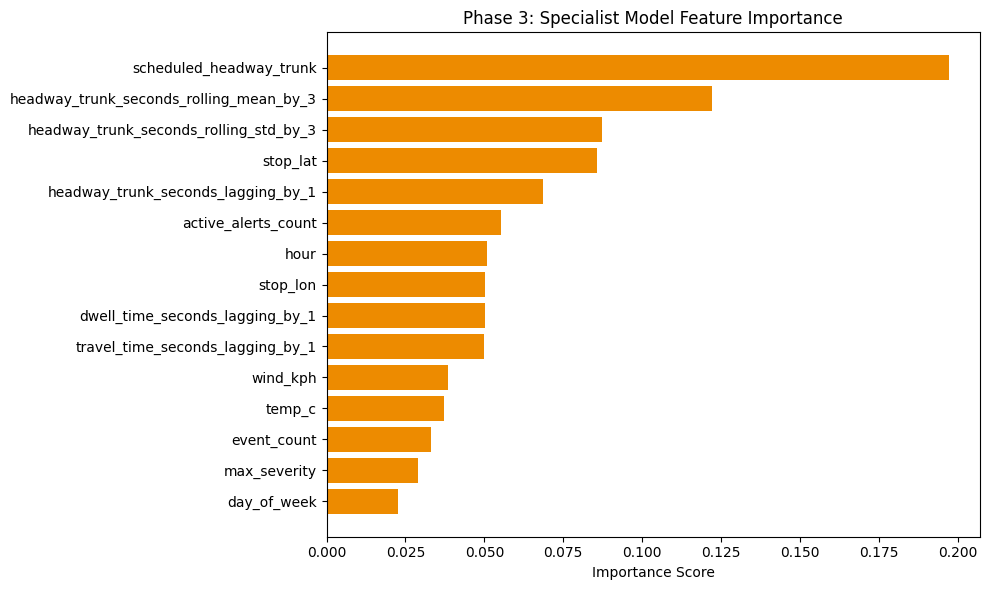

In [0]:
import pandas as pd
import matplotlib.pyplot as plt

importances = rf_model_specialist.featureImportances.toArray()

feature_importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': importances
}).sort_values(by='Importance', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'][-15:], feature_importance_df['Importance'][-15:], color='#ED8B00')
plt.title("Phase 3: Specialist Model Feature Importance")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

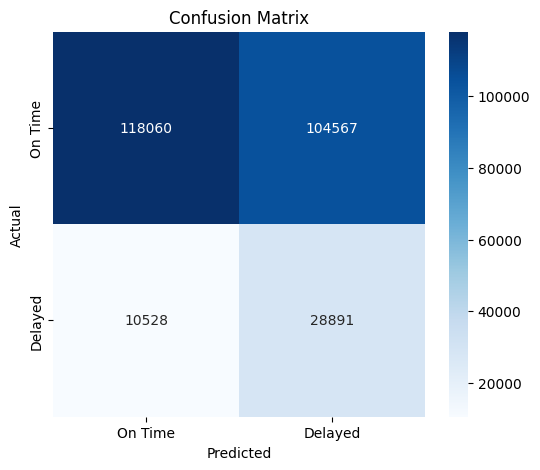

In [0]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix


predictions = rf_model.transform(test_df)

y_true = predictions.select("is_delayed").toPandas()
y_pred = predictions.select("prediction").toPandas()

cm = confusion_matrix(y_true, y_pred)

# Plot
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['On Time', 'Delayed'], 
            yticklabels=['On Time', 'Delayed'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()